<a href="https://colab.research.google.com/github/Aniketyadav29/Data-Science-Tutorial/blob/main/Module_8_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN AUGMENTATION**

CNN Augmentation, often referred to as Data Augmentation in the context of Convolutional Neural Networks (CNNs), is a technique used to increase the diversity of the training dataset without actually collecting new data. This is crucial for improving the generalization ability of CNN models and reducing overfitting, especially when working with limited datasets.

Common augmentation techniques include:

Image Transformations: Rotating, flipping (horizontal/vertical), shifting (width/height), zooming, shearing, and brightness adjustments.
Color Augmentation: Changing hue, saturation, and contrast.
Noise Injection: Adding random noise to images.
CutOut/Mixup: Techniques that selectively remove or blend parts of images to create new training examples.
By generating varied versions of existing images, data augmentation helps the CNN learn more robust features and become less sensitive to the specific characteristics of the original training samples.

### Data Augmentation with TensorFlow

TensorFlow provides a convenient `tf.keras.layers.experimental.preprocessing` module that offers various layers for on-the-fly data augmentation. These layers can be integrated directly into your model or used to preprocess your dataset.

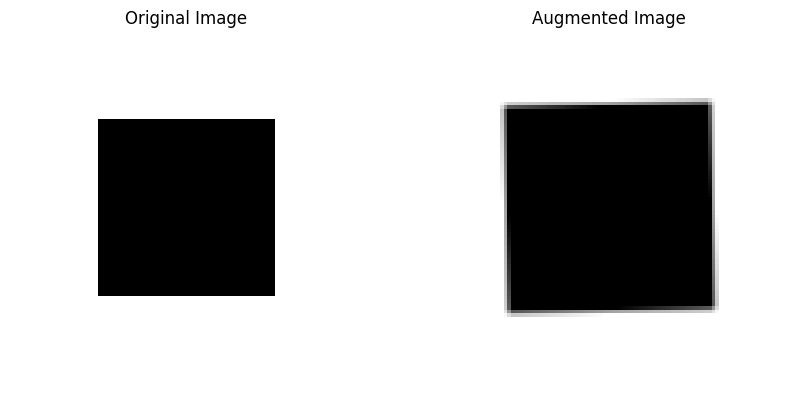

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Create a dummy image for demonstration (e.g., a simple white square with a black center)
# In a real scenario, you would load an actual image.
img_size = 100
img = np.ones((img_size, img_size, 3), dtype=np.uint8) * 255 # White background
img[25:75, 25:75, :] = 0 # Black square in the middle

# Convert numpy array to TensorFlow tensor and add a batch dimension
image_tensor = tf.constant(img, dtype=tf.float32)
image_batch = tf.expand_dims(image_tensor, 0) # Add batch dimension

# Define a sequential model with augmentation layers
# These layers can be part of your main model or a standalone preprocessing pipeline
augment_model = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2) # Adjust contrast randomly
])

# Apply augmentation
augmented_image_batch = augment_model(image_batch)
augmented_image = augmented_image_batch[0].numpy().astype(np.uint8)

# Display the original and augmented image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title("Augmented Image")
plt.axis('off')

plt.show()


This example creates a dummy image and applies a series of random augmentations (flip, rotation, zoom, contrast) using `tf.keras.layers`. When you run this cell multiple times, you'll see different augmented versions of the original image, demonstrating the randomness of these layers.